# Surface-code X-noise Monte Carlo with BP and BP+OSD-0

In this notebook, we study the threshold and runtime of native BP and BP+OSD+CS-0. We consider qubit planar/rotated surface code under uncorrelated **X-only** code-capacity noise.

It uses:
- `surface_code_X_stabilizers(d)` and `surface_code_Z_stabilizers(d)` to build the CSS checks,
- `bp_osd_cs_decode(...; osd_order=0)` as the BP+OSD decoder for the X-error sector,
- `bp_min_sum_decode()` as the native BP decoder for the X-error sector,
- a logical-success test based on whether the residual X error lies in the row space of the X stabilizers.

Conclusion:
- We find that the threshold is 9.2% for BP+OSD, consistent with the value obtained in Roffe's benchmark in https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.2.043423
- We find that there is no threshold for native BP, consistent with https://arxiv.org/pdf/2307.14989

In [ ]:
using Plots
using Distributed
using LinearAlgebra
using JLD2

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
end

@everywhere begin
    using LatticeAlgorithms
    using LinearAlgebra
    using Dates
end

: 

In [2]:
println("num_cores = $(num_cores)")

num_cores = 8


In [3]:
@everywhere function stabilizer_dict_to_check_matrix(dict::Dict{Int64, Vector{Int64}}, n::Int)
    H = zeros(Int64, length(dict), n)
    for (row_idx, qubits) in sort(collect(dict); by=first)
        H[row_idx, qubits] .= 1
    end
    return H
end

@everywhere function gf2_rank(H::AbstractMatrix{<:Integer})
    _, pivots = gf2_rref(H)
    return length(pivots)
end

@everywhere function is_in_rowspace_mod2(v::AbstractVector{<:Integer}, H::AbstractMatrix{<:Integer})
    vrow = reshape(mod.(Int64.(v), 2), 1, :)
    return gf2_rank(H) == gf2_rank(vcat(mod.(Int64.(H), 2), vrow))
end

@everywhere function run_surface_xnoise_batch(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
    λ::Int=60,
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_osd_cs_decode(
            HZ, sx, p;
            max_iter=max_iter,
            λ=λ,
            osd_order=0,
            bp_method=:ms,
        )

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [4]:
type_lattice = "qubit_surface_bp_osd0_xnoise"

num_samples = Int(1e5)
dmin, dmax = 3, 9
drange = dmin:2:dmax

prange = (7.0:0.25:11.0) / 100

max_iter_factor = 1
λ = 60

pd_range = [(Float64(p), Int(d)) for p in prange for d in drange]
println(pd_range)

num_samples_each_core = Int(ceil(num_samples / num_cores))
num_total_samples = num_samples_each_core * num_cores
println((num_samples_each_core=num_samples_each_core, num_samples=num_samples, num_total_samples=num_total_samples))

logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

[(0.07, 3), (0.07, 5), (0.07, 7), (0.07, 9), (0.0725, 3), (0.0725, 5), (0.0725, 7), (0.0725, 9), (0.075, 3), (0.075, 5), (0.075, 7), (0.075, 9), (0.0775, 3), (0.0775, 5), (0.0775, 7), (0.0775, 9), (0.08, 3), (0.08, 5), (0.08, 7), (0.08, 9), (0.0825, 3), (0.0825, 5), (0.0825, 7), (0.0825, 9), (0.085, 3), (0.085, 5), (0.085, 7), (0.085, 9), (0.0875, 3), (0.0875, 5), (0.0875, 7), (0.0875, 9), (0.09, 3), (0.09, 5), (0.09, 7), (0.09, 9), (0.0925, 3), (0.0925, 5), (0.0925, 7), (0.0925, 9), (0.095, 3), (0.095, 5), (0.095, 7), (0.095, 9), (0.0975, 3), (0.0975, 5), (0.0975, 7), (0.0975, 9), (0.1, 3), (0.1, 5), (0.1, 7), (0.1, 9), (0.1025, 3), (0.1025, 5), (0.1025, 7), (0.1025, 9), (0.105, 3), (0.105, 5), (0.105, 7), (0.105, 9), (0.1075, 3), (0.1075, 5), (0.1075, 7), (0.1075, 9), (0.11, 3), (0.11, 5), (0.11, 7), (0.11, 9)]
(num_samples_each_core = 12500, num_samples = 100000, num_total_samples = 100000)


In [ ]:
@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
                λ=λ,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    λ=λ,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=5.988364042, 2026-03-24T10:00:08.071
      From worker 2:	2/68, d=5, p=0.07, walltime=5.86174375, 2026-03-24T10:00:14.175
      From worker 2:	3/68, d=7, p=0.07, walltime=24.370156125, 2026-03-24T10:00:38.547
      From worker 2:	4/68, d=9, p=0.07, walltime=107.0657855, 2026-03-24T10:02:25.612
      From worker 2:	5/68, d=3, p=0.0725, walltime=1.597700125, 2026-03-24T10:02:27.219
      From worker 2:	6/68, d=5, p=0.0725, walltime=7.731793541, 2026-03-24T10:02:34.962
      From worker 2:	7/68, d=7, p=0.0725, walltime=29.539763458, 2026-03-24T10:03:04.504
      From worker 2:	8/68, d=9, p=0.0725, walltime=81.435622792, 2026-03-24T10:04:25.939
      From worker 2:	9/68, d=3, p=0.075, walltime=1.387974084, 2026-03-24T10:04:27.334
      From worker 2:	10/68, d=5, p=0.075, walltime=12.340385375, 2026-03-24T10:04:39.675
      From worker 2:	11/68, d=7, p=0.075, walltime=24.307912167, 2026-03-24T10:05:03.985
      From worker 2:	12/68, d=9, p=0.

In [6]:
sort(load(fn)["p_success_list"])

OrderedCollections.OrderedDict{Tuple{Float64, Int64}, Float64} with 68 entries:
  (0.07, 3)   => 0.93375
  (0.07, 5)   => 0.94259
  (0.07, 7)   => 0.95247
  (0.07, 9)   => 0.95761
  (0.0725, 3) => 0.92946
  (0.0725, 5) => 0.9388
  (0.0725, 7) => 0.94627
  (0.0725, 9) => 0.95324
  (0.075, 3)  => 0.92439
  (0.075, 5)  => 0.93294
  (0.075, 7)  => 0.94112
  (0.075, 9)  => 0.94879
  (0.0775, 3) => 0.92065
  (0.0775, 5) => 0.92891
  (0.0775, 7) => 0.93575
  (0.0775, 9) => 0.94167
  (0.08, 3)   => 0.91715
  (0.08, 5)   => 0.92339
  (0.08, 7)   => 0.92929
  (0.08, 9)   => 0.93405
  (0.0825, 3) => 0.91348
  (0.0825, 5) => 0.91877
  (0.0825, 7) => 0.9228
  (0.0825, 9) => 0.92955
  (0.085, 3)  => 0.90762
  ⋮           => ⋮

In [7]:
function get_grid_from_dict(dict::Dict, drange, prange)
    return [[dict[(Float64(p), Int(d))] for d in drange] for p in prange]
end

p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [0.00011429992812000023, 0.00033301012845999954, 0.0015061959764199992, 0.006482979945069997]
 [6.782500942999999e-5, 0.0004341766335899997, 0.0017190645168100006, 0.0051818707876600005]
 [5.338711009999998e-5, 0.0004725221624000007, 0.0016280686488400033, 0.004682499113040007]
 [4.082044058000004e-5, 0.00034598841768999916, 0.0013322559331600025, 0.005776775763279999]
 [4.1295536139999946e-5, 0.00029669813828, 0.0017036683101600007, 0.005336501002619995]
 [6.562616445999999e-5, 0.00040189834359999956, 0.0018071267831799996, 0.005364307391380005]
 [5.258972230000007e-5, 0.00036410111635000036, 0.0019830583311200014, 0.006306296740389992]
 [7.659732309000002e-5, 0.0004860570751499995, 0.0017442823534599967, 0.005157819346919997]
 [5.299769789000005e-5, 0.00036304291664000045, 0.0015447559842700004, 0.005569794936090004]
 [5.36050986399999e-5, 0.00037865258721000045, 0.0018306783667999987, 0.00616692537685]
 [5.711469865999986e-5, 0.000445785700389999

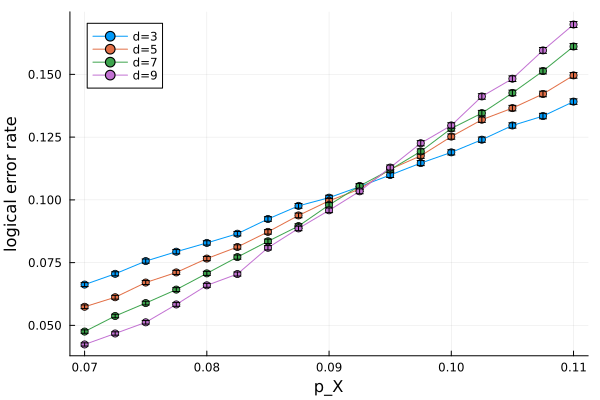

In [11]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

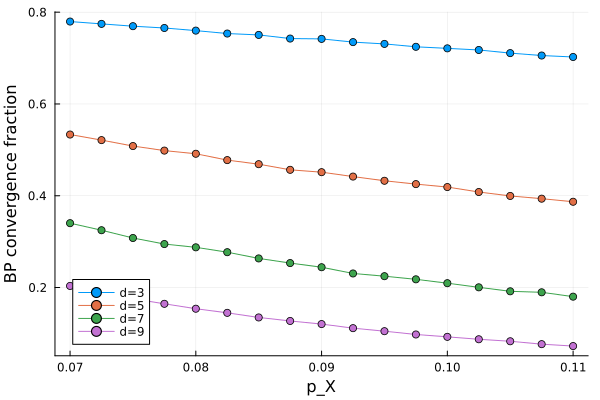

In [12]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

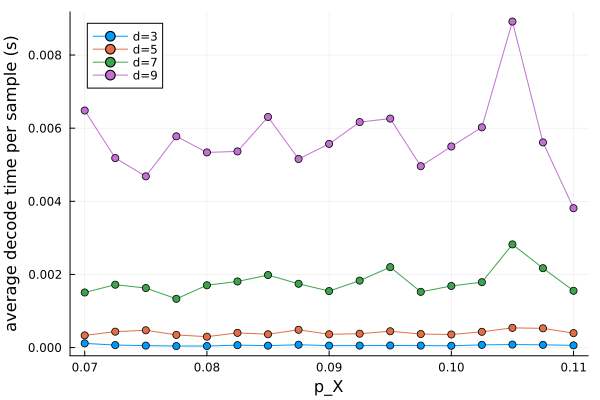

In [13]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)

## Notes

- This notebook decodes **X-only** noise, so it uses the **Z-check matrix** as the input parity-check matrix to `bp_osd_cs_decode`.
- Success is declared when the residual X error lies in the row space of the X stabilizers, i.e. when it is a stabilizer and not a logical X operator.
- The decoder is run with `osd_order = 0`, so this notebook measures **BP+OSD-0**, not higher-order combination sweep.


# Benchmark with bare BP

In [7]:
@everywhere function run_surface_xnoise_batch_bare_bp(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_min_sum_decode(HZ, sx, p; max_iter=max_iter)

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [8]:
type_lattice = "qubit_surface_bp_xnoise"
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch_bare_bp(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=0.741453042, 2026-03-24T14:20:05.096
      From worker 2:	2/68, d=5, p=0.07, walltime=1.300566, 2026-03-24T14:20:06.429
      From worker 2:	3/68, d=7, p=0.07, walltime=5.778192209, 2026-03-24T14:20:12.218
      From worker 2:	4/68, d=9, p=0.07, walltime=17.105551, 2026-03-24T14:20:29.330
      From worker 2:	5/68, d=3, p=0.0725, walltime=0.176795792, 2026-03-24T14:20:29.508
      From worker 2:	6/68, d=5, p=0.0725, walltime=1.175633, 2026-03-24T14:20:30.687
      From worker 2:	7/68, d=7, p=0.0725, walltime=6.260940833, 2026-03-24T14:20:36.964
      From worker 2:	8/68, d=9, p=0.0725, walltime=18.927747708, 2026-03-24T14:20:55.893
      From worker 2:	9/68, d=3, p=0.075, walltime=0.218922333, 2026-03-24T14:20:56.114
      From worker 2:	10/68, d=5, p=0.075, walltime=1.203858417, 2026-03-24T14:20:57.319
      From worker 2:	11/68, d=7, p=0.075, walltime=5.75986475, 2026-03-24T14:21:03.080
      From worker 2:	12/68, d=9, p=0.075, walltim

In [9]:
sort(load(fn)["p_success_list"])

OrderedCollections.OrderedDict{Tuple{Float64, Int64}, Float64} with 68 entries:
  (0.07, 3)   => 0.73966
  (0.07, 5)   => 0.51383
  (0.07, 7)   => 0.32872
  (0.07, 9)   => 0.19789
  (0.0725, 3) => 0.73296
  (0.0725, 5) => 0.50304
  (0.0725, 7) => 0.31814
  (0.0725, 9) => 0.1843
  (0.075, 3)  => 0.72363
  (0.075, 5)  => 0.48805
  (0.075, 7)  => 0.29977
  (0.075, 9)  => 0.17076
  (0.0775, 3) => 0.71392
  (0.0775, 5) => 0.47684
  (0.0775, 7) => 0.28839
  (0.0775, 9) => 0.16116
  (0.08, 3)   => 0.7085
  (0.08, 5)   => 0.46091
  (0.08, 7)   => 0.27784
  (0.08, 9)   => 0.1513
  (0.0825, 3) => 0.6998
  (0.0825, 5) => 0.45183
  (0.0825, 7) => 0.26341
  (0.0825, 9) => 0.14161
  (0.085, 3)  => 0.68938
  ⋮           => ⋮

In [10]:
function get_grid_from_dict(dict::Dict, drange, prange)
    return [[dict[(Float64(p), Int(d))] for d in drange] for p in prange]
end

p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [1.3887278399999988e-5, 6.535454443999989e-5, 0.00030107735265000026, 0.0008789940106200002]
 [1.1445249779999977e-5, 6.314224675e-5, 0.00031892053763999973, 0.0009714618956600026]
 [1.0717360739999959e-5, 6.559195645999996e-5, 0.00030346417998999966, 0.0010035209223199996]
 [1.042423453999993e-5, 6.613413679000004e-5, 0.00029475433595000007, 0.0009349420136499997]
 [2.403387850000006e-5, 8.265487032000007e-5, 0.0003436941898400005, 0.0010624997593199996]
 [1.301532001999997e-5, 6.504047726000002e-5, 0.00028599985357, 0.0008960108348000009]
 [1.0722509759999964e-5, 6.818418972000008e-5, 0.00029125337397000004, 0.0009179095786100005]
 [1.2088264779999967e-5, 7.09570005500001e-5, 0.00027614913469999985, 0.0009756906637299995]
 [1.2568224019999959e-5, 7.236774675000007e-5, 0.0002922286039200004, 0.0010144701548599983]
 [1.2070048669999964e-5, 6.688073093000002e-5, 0.0002928894319900001, 0.0009286320932100023]
 [1.1626640859999964e-5, 7.376295497000001e

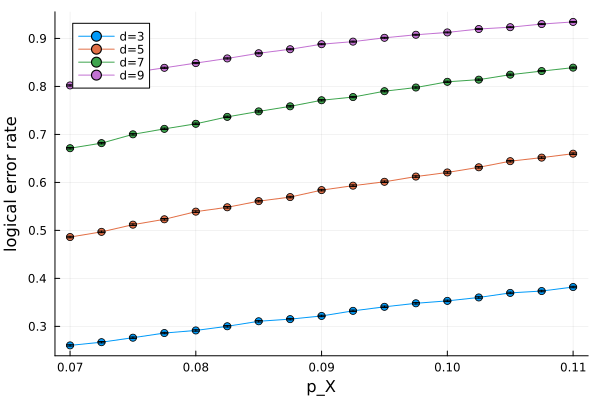

In [11]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

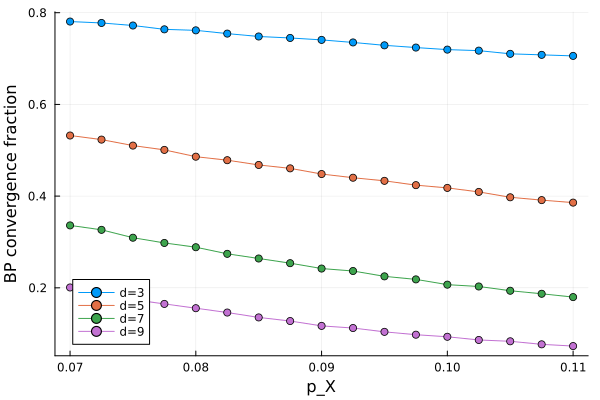

In [12]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

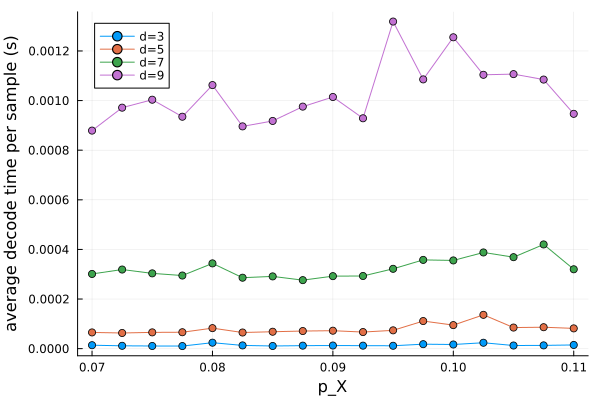

In [13]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)